Данные: [резюме HH](https://drive.google.com/file/d/1Kb78mAWYKcYlellTGhIjPI-bCcKbGuTn/view). CSV и ExchangeRates.zip находятся в папке data.

# Анализ резюме HeadHunter

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.max_colwidth', 80)

# Исследование структуры данных

1. Загрузка данных.

In [2]:
data_path = Path('data/dst-3.0_16_1_hh_database.csv')
if not data_path.exists():
    data_path = Path('../dst-3.0_16_1_hh_database.csv')
data: pd.DataFrame = pd.read_csv(data_path, sep=';')
print('Размер таблицы:', data.shape)

Размер таблицы: (44744, 12)


2. Первые строки.

In [3]:
display(data.head(3))

3–4. Типы столбцов и пропуски.

In [4]:
data.info()
display(data.isna().sum().rename('Пропуски'))

<class 'pandas.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Пол, возраст                     44744 non-null  str  
 1   ЗП                               44744 non-null  str  
 2   Ищет работу на должность:        44744 non-null  str  
 3   Город, переезд, командировки     44744 non-null  str  
 4   Занятость                        44744 non-null  str  
 5   График                           44744 non-null  str  
 6   Опыт работы                      44576 non-null  str  
 7   Последнее/нынешнее место работы  44743 non-null  str  
 8   Последняя/нынешняя должность     44742 non-null  str  
 9   Образование и ВУЗ                44744 non-null  str  
 10  Обновление резюме                44744 non-null  str  
 11  Авто                             44744 non-null  str  
dtypes: str(12)
memory usage: 4.1 MB


Пол, возраст                         0
ЗП                                   0
Ищет работу на должность:            0
Город, переезд, командировки         0
Занятость                            0
График                               0
Опыт работы                        168
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
Образование и ВУЗ                    0
Обновление резюме                    0
Авто                                 0
Name: Пропуски, dtype: int64

5. Статистика признаков.

In [5]:
display(data.describe(include='all').T)

# Преобразование данных

1. Уровень образования.

In [6]:
def get_education(value: str) -> str:
    words = value.lower().split()
    if words[0] in ('неоконченное', 'среднее') and words[1] in ('высшее', 'специальное'):
        return ' '.join(words[:2])
    return words[0]

data['Образование'] = data['Образование и ВУЗ'].apply(get_education)
data = data.drop(columns='Образование и ВУЗ')
display(data['Образование'].value_counts())

Образование
высшее                 33863
среднее специальное     5765
неоконченное высшее     4557
среднее                  559
Name: count, dtype: int64

2. Пол и возраст.

In [7]:
data['Пол'] = data['Пол, возраст'].str[0]
data['Возраст'] = data['Пол, возраст'].str.extract(r',\s*(\d+)', expand=False).astype(int)
data = data.drop(columns='Пол, возраст')
print('Доля женщин, %:', round(data['Пол'].eq('Ж').mean() * 100, 2))
print('Средний возраст:', round(data['Возраст'].mean(), 1))

Доля женщин, %: 19.07
Средний возраст: 32.2


3. Опыт в месяцах. «Не указано» считаем пропуском.

In [8]:
def get_experience(value: object) -> float:
    if pd.isna(value) or value == 'Не указано':
        return np.nan
    match = re.match(r'Опыт работы\s*(?:(\d+)\s*(?:лет|года|год))?\s*(?:(\d+)\s*месяц\w*)?', str(value))
    if match is None:
        raise ValueError('Не удалось разобрать опыт работы')
    return float(int(match[1] or 0) * 12 + int(match[2] or 0))

data['Опыт работы (месяц)'] = data['Опыт работы'].apply(get_experience)
data = data.drop(columns='Опыт работы')
print('Медиана опыта, месяцев:', data['Опыт работы (месяц)'].median())

Медиана опыта, месяцев: 100.0


4. Город, переезд и командировки.

In [9]:
million_cities: list[str] = [
    'Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань',
    'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа',
    'Красноярск', 'Пермь', 'Воронеж', 'Волгоград',
]
location = data['Город, переезд, командировки']
city = location.str.split(',').str[0].str.strip()
data['Город'] = city.where(city.isin(['Москва', 'Санкт-Петербург']), 'другие')
data.loc[city.isin(million_cities), 'Город'] = 'город-миллионник'
data['Готовность к переезду'] = ~location.str.contains(r'не готова? к переезду')
data['Готовность к командировкам'] = (
    location.str.contains('командировкам')
    & ~location.str.contains(r'не готова? к командировкам')
)
data = data.drop(columns='Город, переезд, командировки')
display(data['Город'].value_counts(normalize=True).mul(100).round(1))
print('Готовы и к переезду, и к командировкам, %:', round(
    (data['Готовность к переезду'] & data['Готовность к командировкам']).mean() * 100,
))

Город
Москва              37.1
другие              35.4
город-миллионник    16.4
Санкт-Петербург     11.0
Name: proportion, dtype: float64

Готовы и к переезду, и к командировкам, %: 32


5. Занятость и график.

In [10]:
for column in ['Занятость', 'График']:
    categories = data[column].str.get_dummies(sep=', ').astype(bool)
    data = pd.concat([data.drop(columns=column), categories], axis=1)
print('Проектная работа и волонтерство:', (data['проектная работа'] & data['волонтерство']).sum())
print('Вахтовый метод и гибкий график:', (data['вахтовый метод'] & data['гибкий график']).sum())

Проектная работа и волонтерство: 436
Вахтовый метод и гибкий график: 2311


6. Зарплата в рублях по курсу на дату резюме.

Курс за единицу валюты: close / proportion.

In [11]:
rates: pd.DataFrame = pd.read_csv('data/ExchangeRates.zip')
rates['date'] = pd.to_datetime(rates['date'], format='%d/%m/%y')
rates['rate'] = rates['close'] / rates['proportion']
data['Обновление резюме'] = pd.to_datetime(data['Обновление резюме'], dayfirst=True).dt.normalize()
currency = data['ЗП'].str.split().str[-1].replace({
    'грн.': 'UAH', 'бел.руб.': 'BYN', 'сум': 'UZS',
})
amount = data['ЗП'].str.replace(r'[^\d]', '', regex=True).astype(float)
keys = pd.MultiIndex.from_arrays([currency, data['Обновление резюме']], names=['currency', 'date'])
conversion = pd.Series(
    rates.set_index(['currency', 'date'])['rate'].reindex(keys).to_numpy(),
    index=data.index,
)
conversion.loc[currency.eq('руб.')] = 1
assert conversion.notna().all()
data['ЗП (руб)'] = amount * conversion
data = data.drop(columns='ЗП')
print('Медианная желаемая зарплата, руб.:', round(data['ЗП (руб)'].median()))

Медианная желаемая зарплата, руб.: 59019


# Исследование зависимостей в данных

1. Распределение возраста.

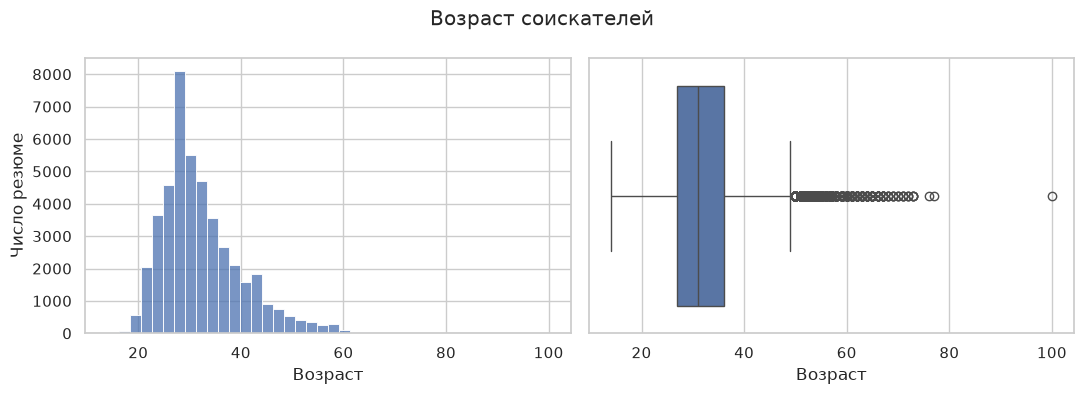

count    44744.000000
mean        32.196741
std          7.929800
min         14.000000
25%         27.000000
50%         31.000000
75%         36.000000
max        100.000000
Name: Возраст, dtype: float64

Мода: [30]


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=data, x='Возраст', bins=40, ax=axes[0])
sns.boxplot(data=data, x='Возраст', ax=axes[1])
axes[0].set_ylabel('Число резюме')
fig.suptitle('Возраст соискателей')
plt.tight_layout()
plt.show()
display(data['Возраст'].describe())
print('Мода:', data['Возраст'].mode().tolist())

Самый частый возраст 30 лет, медиана 31 год. Основная масса соискателей примерно от 20 до 40 лет, половина находится в диапазоне 27–36 лет. Полный диапазон 14–100 лет. Возраст 100 лет выглядит подозрительно; 14–15 лет тоже стоит проверить, хотя сам по себе такой возраст возможен.

2. Распределение опыта работы в месяцах.

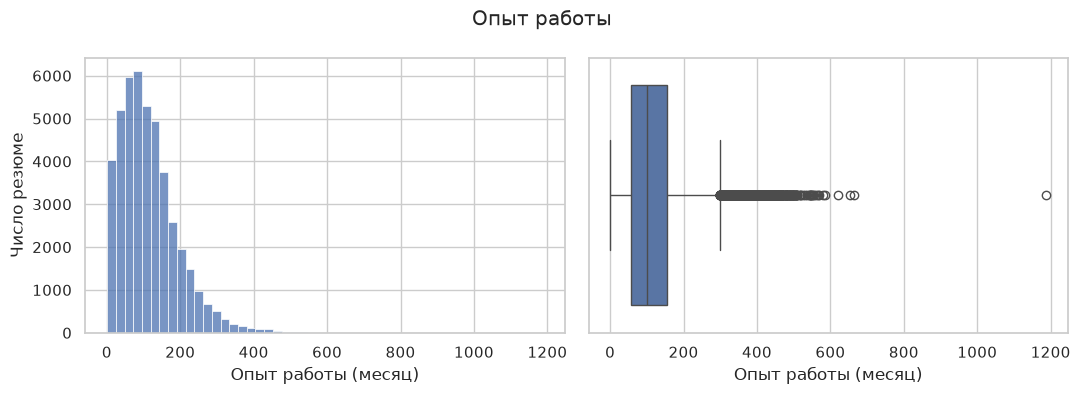

count    44574.000000
mean       114.418944
std         79.047861
min          1.000000
25%         57.000000
50%        100.000000
75%        154.000000
max       1188.000000
Name: Опыт работы (месяц), dtype: float64

Мода: [81.0]


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data=data, x='Опыт работы (месяц)', bins=50, ax=axes[0])
sns.boxplot(data=data, x='Опыт работы (месяц)', ax=axes[1])
axes[0].set_ylabel('Число резюме')
fig.suptitle('Опыт работы')
plt.tight_layout()
plt.show()
display(data['Опыт работы (месяц)'].describe())
print('Мода:', data['Опыт работы (месяц)'].mode().tolist())

Мода 81 месяц, медиана 100 месяцев. Основная масса значений до 200 месяцев, половина лежит между 57 и 154 месяцами. Минимум 1 месяц, максимум 1188 месяцев, то есть 99 лет. Такой опыт явно подозрителен, особенно если сравнить его с возрастом.

3. Распределение зарплаты, логарифмическая шкала.

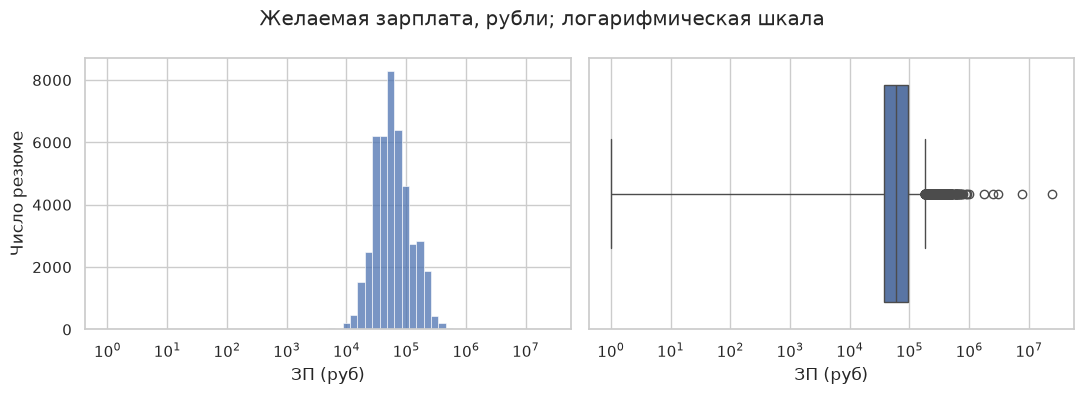

count    4.474400e+04
mean     7.653354e+04
std      1.359315e+05
min      1.000000e+00
25%      3.708220e+04
50%      5.901900e+04
75%      9.500000e+04
max      2.430488e+07
Name: ЗП (руб), dtype: float64

Зарплата выше миллиона: 5


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(data['ЗП (руб)'], bins=60, log_scale=True, ax=axes[0])
sns.boxplot(x=data['ЗП (руб)'], ax=axes[1])
axes[1].set_xscale('log')
axes[0].set_ylabel('Число резюме')
fig.suptitle('Желаемая зарплата, рубли; логарифмическая шкала')
plt.tight_layout()
plt.show()
display(data['ЗП (руб)'].describe())
print('Зарплата выше миллиона:', data['ЗП (руб)'].gt(1_000_000).sum())

Медиана около 59 тыс. руб., половина значений между 37 и 95 тыс. руб. Распределение с длинным правым хвостом. Минимум 1 рубль, максимум около 24,3 млн руб.; выше миллиона указано 5 зарплат. Это кандидаты на выбросы. Маленькие суммы тоже могут быть ошибками ввода.

4. Медианная зарплата по образованию, без значений от миллиона рублей.

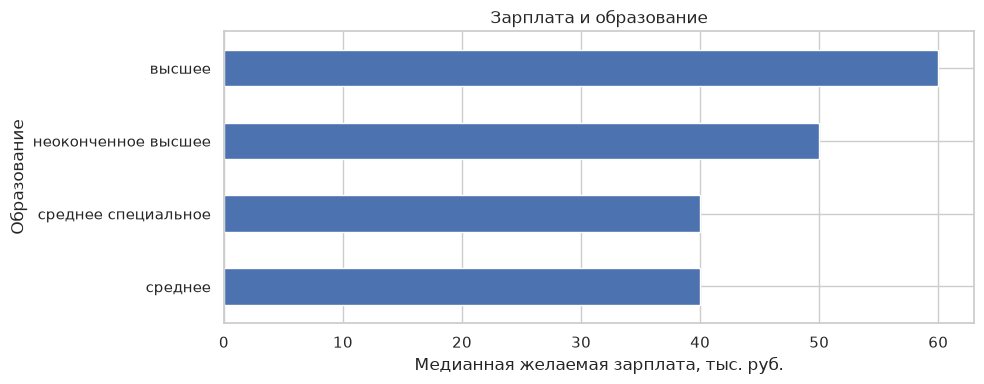

Образование
среднее                40000.0
среднее специальное    40000.0
неоконченное высшее    50000.0
высшее                 60000.0
Name: ЗП (руб), dtype: float64

In [15]:
filtered = data[data['ЗП (руб)'] < 1_000_000]
education_salary = filtered.groupby('Образование')['ЗП (руб)'].median().sort_values()
education_salary.div(1000).plot.barh()
plt.xlabel('Медианная желаемая зарплата, тыс. руб.')
plt.title('Зарплата и образование')
plt.tight_layout()
plt.show()
display(education_salary)

Выше всего медиана у соискателей с высшим образованием: 60 тыс. руб. Для неоконченного высшего это 50 тыс., для среднего и среднего специального по 40 тыс. Образование выглядит полезным признаком для модели, хотя здесь также могут влиять возраст и профессия.

5. Распределение зарплат по городам, без значений от миллиона рублей.

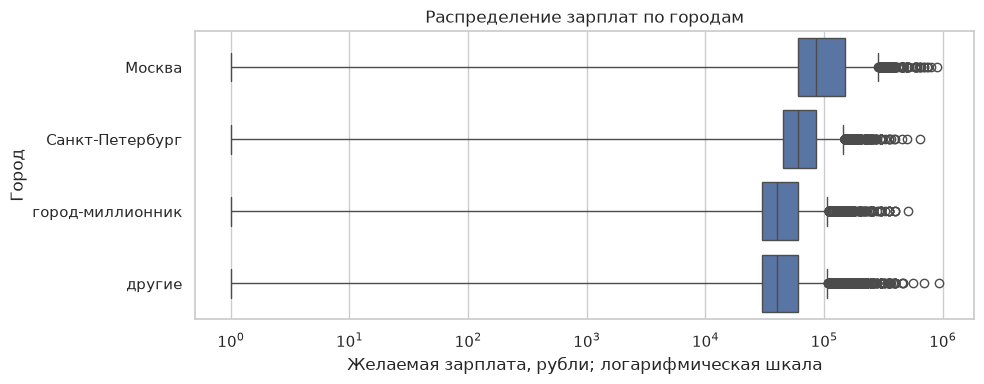

,min,median,max
Город,,,
Москва,1.0,85000.0,900000.0
Санкт-Петербург,1.0,60000.0,645171.0
город-миллионник,1.0,40000.0,511681.6
другие,1.0,40000.0,923983.0


In [16]:
city_order: list[str] = ['Москва', 'Санкт-Петербург', 'город-миллионник', 'другие']
sns.boxplot(data=filtered, x='ЗП (руб)', y='Город', order=city_order)
plt.xscale('log')
plt.xlabel('Желаемая зарплата, рубли; логарифмическая шкала')
plt.title('Распределение зарплат по городам')
plt.tight_layout()
plt.show()
display(filtered.groupby('Город')['ЗП (руб)'].agg(['min', 'median', 'max']))

В Москве медиана 85 тыс. руб., в Санкт-Петербурге 60 тыс., в остальных двух группах по 40 тыс. В Москве выше и центральная часть распределения. Полный размах большой во всех группах, максимальный у «других»: почти 924 тыс. руб. Город стоит учитывать в прогнозе.

6. Зарплата и готовность к поездкам.

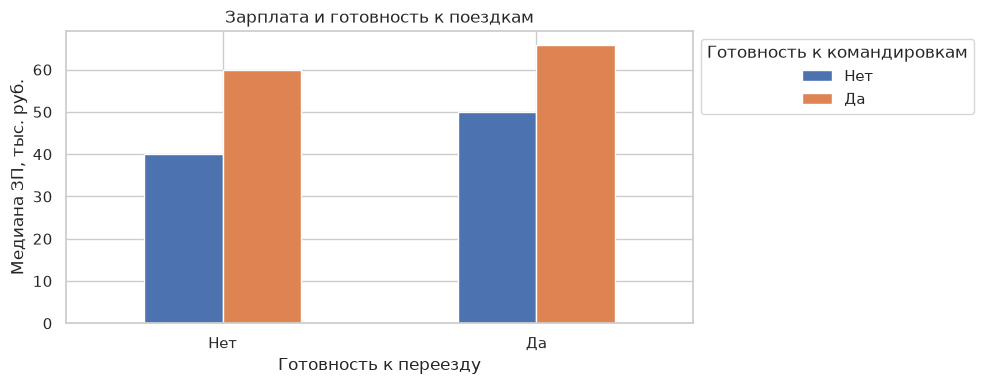

Готовность к командировкам,False,True
Готовность к переезду,,
False,40000.0,60000.000
True,50000.0,65849.455


In [17]:
mobility_salary = data.pivot_table(
    index='Готовность к переезду', columns='Готовность к командировкам',
    values='ЗП (руб)', aggfunc='median',
)
mobility_salary.div(1000).rename(index={False: 'Нет', True: 'Да'}, columns={False: 'Нет', True: 'Да'}).plot.bar(rot=0)
plt.ylabel('Медиана ЗП, тыс. руб.')
plt.legend(title='Готовность к командировкам', loc='upper left', bbox_to_anchor=(1, 1))
plt.title('Зарплата и готовность к поездкам')
plt.tight_layout()
plt.show()
display(mobility_salary)

У готовых и к переезду, и к командировкам медиана около 65,8 тыс. руб. У тех, кто не готов ни к тому ни к другому, 40 тыс. Только командировки соответствуют 60 тыс., только переезд 50 тыс. В этой выборке готовность к поездкам связана с более высокими ожиданиями.

7. Медианная зарплата по возрасту и образованию.

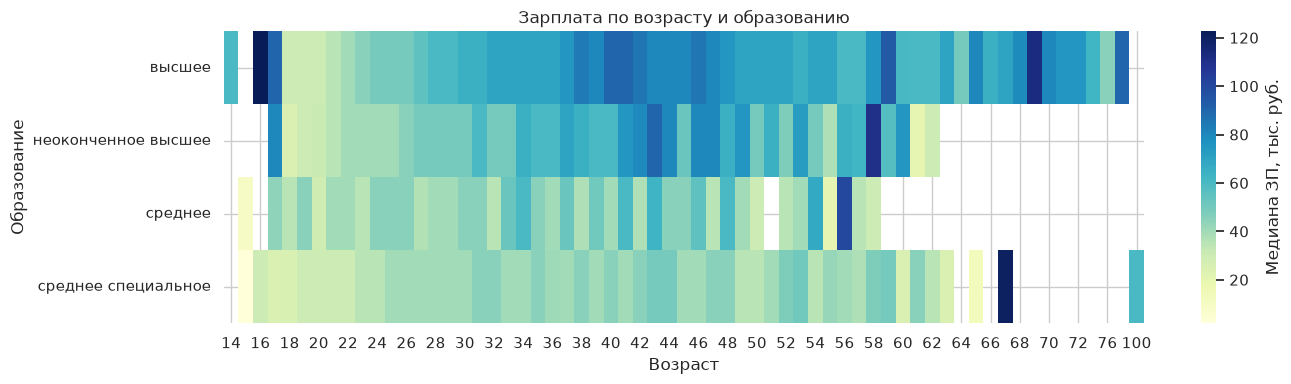

In [18]:
age_education = data.pivot_table(
    index='Образование', columns='Возраст', values='ЗП (руб)', aggfunc='median',
)
plt.figure(figsize=(14, 4))
sns.heatmap(age_education / 1000, cmap='YlGnBu', cbar_kws={'label': 'Медиана ЗП, тыс. руб.'})
plt.title('Зарплата по возрасту и образованию')
plt.tight_layout()
plt.show()

У соискателей с высшим и неоконченным высшим образованием ожидания в целом растут от молодого возраста к 35–45 годам. При среднем и среднем специальном образовании рост слабее. В редких возрастах видны скачки: медиана маленькой группы нестабильна. Белые клетки означают отсутствие наблюдений, а не нулевую зарплату.

8. Возраст и опыт работы.

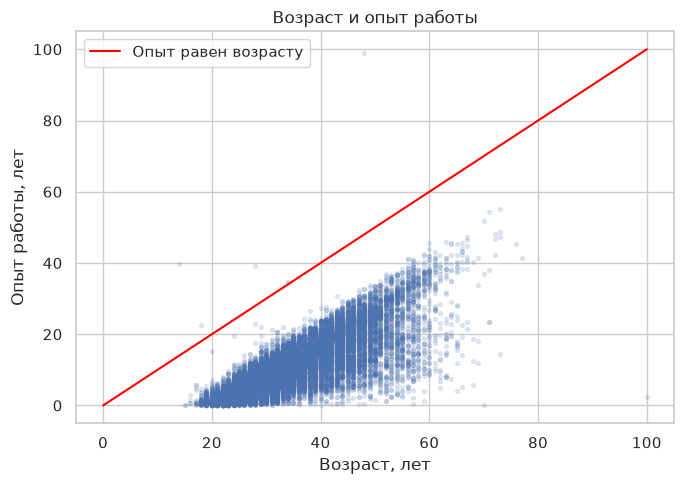

Опыт больше возраста: 7


In [19]:
plt.figure(figsize=(7, 5))
plt.scatter(data['Возраст'], data['Опыт работы (месяц)'] / 12, s=8, alpha=0.15)
plt.plot([0, 100], [0, 100], color='red', label='Опыт равен возрасту')
plt.xlabel('Возраст, лет')
plt.ylabel('Опыт работы, лет')
plt.title('Возраст и опыт работы')
plt.legend()
plt.tight_layout()
plt.show()
print('Опыт больше возраста:', (data['Опыт работы (месяц)'] / 12 > data['Возраст']).sum())

Опыт обычно растёт с возрастом. В 7 записях опыт больше возраста, их удалим. Некоторые точки ниже линии тоже подозрительны: из них следует начало работы в раннем детстве.

Дополнительно: удалённая работа и опыт.

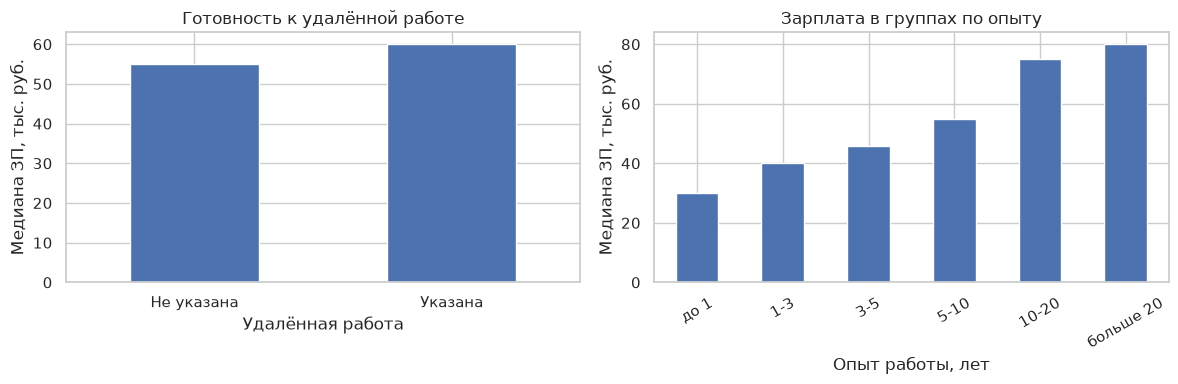

удаленная работа
False    55000.0
True     60000.0
Name: ЗП (руб), dtype: float64

Опыт работы (месяц)
до 1         30000.00
1-3          40000.00
3-5          45898.55
5-10         55000.00
10-20        75000.00
больше 20    80000.00
Name: ЗП (руб), dtype: float64

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
remote_salary = filtered.groupby('удаленная работа')['ЗП (руб)'].median()
remote_salary.div(1000).rename(index={False: 'Не указана', True: 'Указана'}).plot.bar(ax=axes[0], rot=0)
axes[0].set_title('Готовность к удалённой работе')
axes[0].set_xlabel('Удалённая работа')
axes[0].set_ylabel('Медиана ЗП, тыс. руб.')
experience_groups = pd.cut(
    data['Опыт работы (месяц)'] / 12, [0, 1, 3, 5, 10, 20, np.inf],
    labels=['до 1', '1-3', '3-5', '5-10', '10-20', 'больше 20'], include_lowest=True,
)
experience_salary = data.groupby(experience_groups, observed=True)['ЗП (руб)'].median()
experience_salary.div(1000).plot.bar(ax=axes[1], rot=30)
axes[1].set_xlabel('Опыт работы, лет')
axes[1].set_ylabel('Медиана ЗП, тыс. руб.')
axes[1].set_title('Зарплата в группах по опыту')
plt.tight_layout()
plt.show()
display(remote_salary, experience_salary)

У указавших удалённую работу медиана 60 тыс. руб., у остальных 55 тыс. Разница небольшая. По группам опыта связь заметнее: от 30 тыс. при опыте до года до 75 тыс. при 10–20 годах и 80 тыс. при опыте больше 20 лет. Эти сравнения показывают связь признаков с ожиданиями, но не доказывают причинное влияние.

# Очистка данных

1. Полные дубликаты.

In [21]:
print('Полных дубликатов:', data.duplicated().sum())
clean = data.drop_duplicates().copy()

Полных дубликатов: 161


2. Пропуски.

In [22]:
display(clean.isna().sum()[lambda x: x > 0])

Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
Опыт работы (месяц)                168
dtype: int64

3. Удаление строк без места работы или должности, заполнение опыта медианой.

In [23]:
clean = clean.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность']).copy()
clean['Опыт работы (месяц)'] = clean['Опыт работы (месяц)'].fillna(clean['Опыт работы (месяц)'].median())
print('Средний опыт после заполнения:', round(clean['Опыт работы (месяц)'].mean()))

Средний опыт после заполнения: 114


4. Зарплаты вне диапазона 1000–1 000 000 руб.

In [24]:
salary_outliers = ~clean['ЗП (руб)'].between(1000, 1_000_000)
print('Удаляем по зарплате:', salary_outliers.sum())
clean = clean.loc[~salary_outliers].copy()

Удаляем по зарплате: 89


5. Опыт больше возраста.

In [25]:
experience_outliers = clean['Опыт работы (месяц)'] / 12 > clean['Возраст']
print('Удаляем по опыту:', experience_outliers.sum())
clean = clean.loc[~experience_outliers].copy()

Удаляем по опыту: 7


6. Выбросы логарифма возраста: 3 сигмы слева, 4 справа.

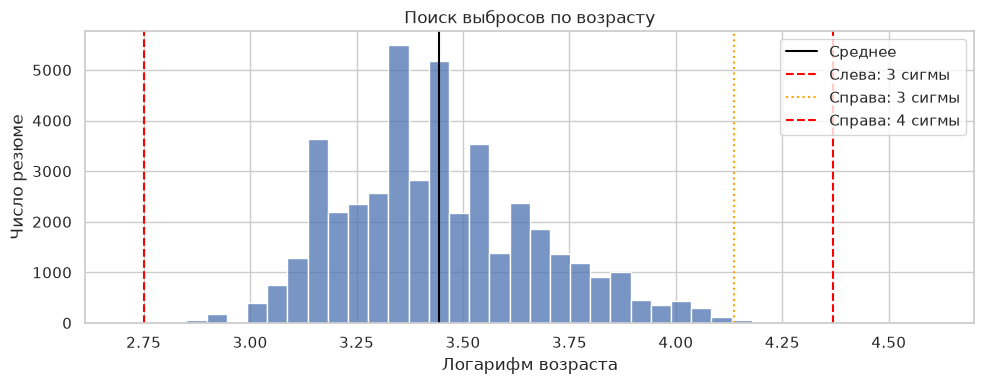

Асимметрия: 0.452
Выбросов по возрасту: 3
Итоговый размер: (44482, 23)
Осталось пропусков: 0


In [26]:
log_age = np.log(clean['Возраст'])
mean = log_age.mean()
std = log_age.std()
left = mean - 3 * std
right = mean + 4 * std
sns.histplot(log_age, bins=40)
plt.axvline(mean, color='black', label='Среднее')
plt.axvline(left, color='red', linestyle='--', label='Слева: 3 сигмы')
plt.axvline(mean + 3 * std, color='orange', linestyle=':', label='Справа: 3 сигмы')
plt.axvline(right, color='red', linestyle='--', label='Справа: 4 сигмы')
plt.xlabel('Логарифм возраста')
plt.ylabel('Число резюме')
plt.title('Поиск выбросов по возрасту')
plt.legend()
plt.tight_layout()
plt.show()
age_outliers = (log_age < left) | (log_age > right)
display(clean.loc[age_outliers, ['Возраст', 'Опыт работы (месяц)', 'ЗП (руб)']])
print('Асимметрия:', round(log_age.skew(), 3))
print('Выбросов по возрасту:', age_outliers.sum())
clean = clean.loc[~age_outliers].copy()
print('Итоговый размер:', clean.shape)
print('Осталось пропусков:', clean.isna().sum().sum())

Распределение скошено вправо, асимметрия 0,452. По заданному правилу удаляются 3 записи: две с возрастом 15 лет и одна со 100 годами. Возраст 15 лет сам по себе не доказывает ошибку.

Осталось 44 482 резюме и 23 признака, пропусков нет.